In [12]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import os, sys
from astropy.io import fits
import healpy as hp

#import pandas as pd
#from pprint import pprint

from scipy.interpolate import interp1d
from scipy import optimize
from scipy.stats import poisson
from scipy import signal

sys.path.append('..')

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file('../notebooks/matplotlibrc')

## 1. Convert everyone to cart

In [2]:
from utils.cart import to_cart
from utils import create_mask as cm

In [3]:
extent = 20  # Semi-extent in degrees
n_pixels = 80  # Number of pixels
pixelsize = 2 * extent / n_pixels
nside = 512

In [16]:
# Load standard templates and convert to Cartesian
options = dict(n_pixels=n_pixels, pixelsize=pixelsize, offset=(0.5,-0.5))
temp = {}
for k in ['gce', 'psc', 'iso', 'dsk', 'bub',
          'p6v11', 'ccwaics', 'ccwapibrem', 'ccwfics', 'ccwfpibrem']:
    temp[k] = to_cart(np.load(f"data/template_{k}_512.npy"), **options)
    print(k, end=' ')

gce psc iso dsk bub p6v11 ccwaics ccwapibrem ccwfics ccwfpibrem 

In [19]:
# masks
mask_ps = np.load("data/fermidata_pscmask_512.npy") == 1

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20., custom_mask=mask_ps), **options) > 0
mask_square = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=False, inner=0, outer=20., custom_mask=mask_ps), **options) > 0
mask_plane = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20.,), **options) > 0

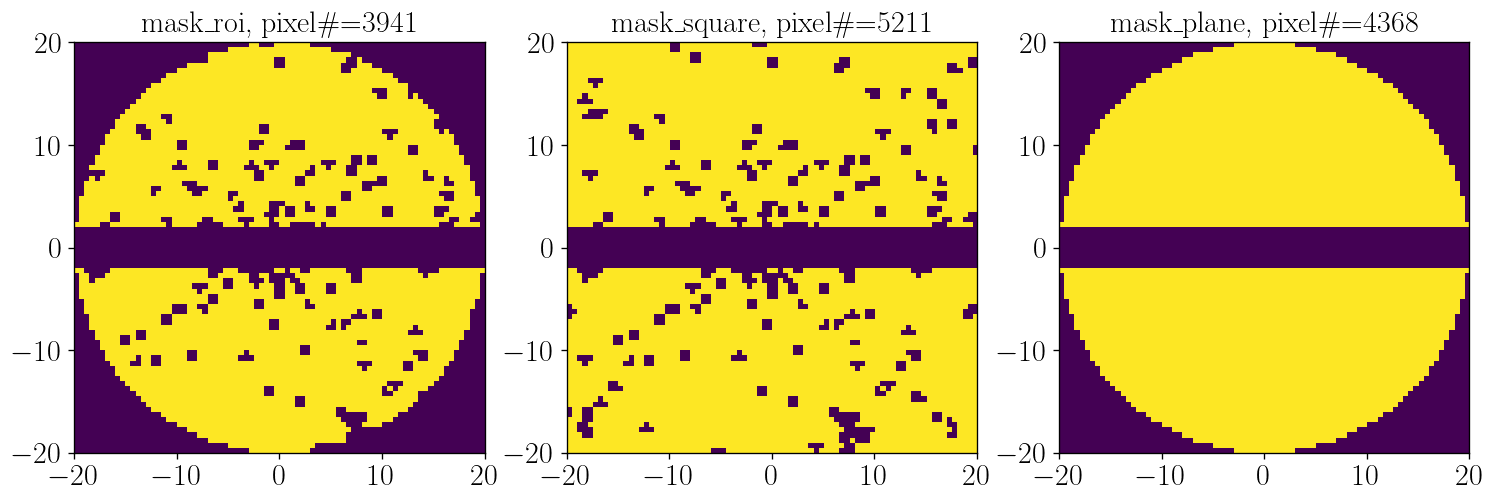

In [25]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
for i, (name, m) in enumerate(zip(['mask_roi', 'mask_square', 'mask_plane'], [mask_roi, mask_square, mask_plane])):
    axs[i].imshow(~m, extent=(-20,20,-20,20))
    axs[i].set(title=f'{name}, pixel\#={np.sum(~m)}')
    #axs[i].set(xlabel='l [deg]', ylabel='b [deg]')

## 2. Poisson fits

In [26]:
def likelihood(theta, data, tmpls, mask=None):
    """ Pixel-wise product Poisson log-likelihood
    """ 
    if mask is None:
        mask = np.zeros_like(tmpls[0], dtype=bool)
    tmpl_sum = np.einsum("ij,i -> j", tmpls[:, ~mask], theta)
    return - poisson.logpmf(data[~mask], tmpl_sum).mean()

In [27]:
# load counts
counts = np.load('data/counts_573week.npy')

In [28]:
# Do fits for p6, Model O, and SkyFACT
diff_models = {
    'p6v11': ['p6v11'],
    'ccwa' : ['ccwaics', 'ccwapibrem'],
    'ccwf' : ['ccwfics', 'ccwfpibrem']
}
other_tmpls = ['gce', 'psc', 'iso', 'bub']

print('\t'.join(['', 'll'] + other_tmpls + ['diff1', 'diff2']))

for m, diff_tmpls in diff_models.items():
    tmpl_tags = other_tmpls + diff_tmpls
    tmpls = np.array([temp[k] for k in tmpl_tags])
    bounds = tuple([(0, 20) for _ in tmpl_tags])
    result = optimize.shgo(likelihood, bounds=bounds, args=(counts, tmpls, mask_roi))
    x_strs = [f'{x:.4f}' for x in result.x]
    print(f'{m}\t{-result.fun:.4f}\t' + '\t'.join(x_strs))

	ll	gce	psc	iso	bub	diff1	diff2
p6v11	-3.1785	1.5926	4.2649	0.0000	0.8314	18.9520
ccwa	-3.1736	2.2400	4.1767	0.0000	0.5397	8.2716	10.7964
ccwf	-3.1697	2.0394	4.0407	0.0000	0.4455	6.9535	11.8117


	ll	gce	psc	iso	bub	diff1	diff2
p6v11	-3.1785	1.5926	4.2649	0.0000	0.8314	18.9520
ccwa	-3.1736	2.2400	4.1767	0.0000	0.5397	8.2716	10.7964
ccwf	-3.1697	2.0394	4.0407	0.0000	0.4455	6.9535	11.8117

In [30]:
import pandas as pd

ImportError: /lib64/libc.so.6: version `GLIBC_2.14' not found (required by /zfs/yitians/anaconda3/envs/fermi/lib/python3.7/site-packages/pandas/_libs/interval.cpython-37m-x86_64-linux-gnu.so)